# Iskanje podatkov PlanetScope in ustvarjanje naročila

Poiščimo satelitske posnetke izbranega območja in ustvarimo naročilo. Naročilo shranimo v zbirko (collection) in ga pošljemo v obdelavo.

## Zahteve

- nameščen Python
- knjižnica requests
- [Planet Account](https://www.planet.com/account/#/)
- API ključ za dostop do Planet API

In [1]:
# Potrebne knjižnice
import os
import json
import math
import requests
from typing import Dict, List, Iterator
# Kartiranje AOI iz GeoJSON datoteke
import contextily as ctx
import matplotlib.pyplot as plt
from shapely.geometry import shape

## Nastavitev API ključa

Najprej moramo nastaviti naš API ključ, da bomo lahko dostopali do Planet API. To lahko storimo tako, da ga shranimo kot spremenljivko okolja ali pa ga neposredno uporabimo v našem Python skriptu.

In [2]:
# Če vaš Planet API ključ ni nastavljen kot spremenljivka okolja, ga lahko prilepite spodaj
if os.environ.get('PL_API_KEY', ''):
    API_KEY = os.environ.get('PL_API_KEY', '')
else:
    API_KEY = 'PASTE_YOUR_API_KEY_HERE'

In [3]:
# Print API key to verify it was loaded correctly (optional)
print(f'API Key Loaded: {API_KEY[:4]}...{API_KEY[-4:]}')

API Key Loaded: PLAK...fdbd


## Določitev območja interesa

Območje interesa (**Area of Interest** ali *AOI*) določa geografsko območje, iz katerega želimo pridobiti podatke.

Pri Data API je to lahko preprost pravokotnik (bounding box) s štirimi vogali ali bolj kompleksna oblika, dokler je definicija zapisana v formatu [GeoJSON](http://geojson.org/).

V tem primeru bomo uporabili preprost pravokotnik. Za enostavno ustvarjanje lahko uporabimo [geojson.io](http://geojson.io/), kjer hitro narišemo obliko in dobimo GeoJSON zapis:

![geojsonio.png](./slike/geojsonio.png)

Za zahtevo Data API potrebujemo samo objekt **geometry**, ki ga lahko preberemo iz GeoJSON datoteke. Ta objekt vsebuje koordinate, ki definirajo naše AOI. Na primer, če imamo GeoJSON datoteko z imenom `aoi.geojson`, lahko preberemo geometrijo.

In [4]:
# Ime datoteke z AOI
aoi_file = './podatki/koper_aoi.geojson'
with open(aoi_file) as f:
    geojson_data = json.load(f)
geojson_geometry = geojson_data['features'][0]['geometry']

In [5]:
# Izpis geometrije AOI, da preverite, ali je pravilno prebrana
print(json.dumps(geojson_geometry, indent=2, ensure_ascii=False))

{
  "type": "Polygon",
  "coordinates": [
    [
      [
        13.66015784,
        45.47778719
      ],
      [
        13.8544984,
        45.47778719
      ],
      [
        13.8544984,
        45.58585118
      ],
      [
        13.66015784,
        45.58585118
      ],
      [
        13.66015784,
        45.47778719
      ]
    ]
  ]
}


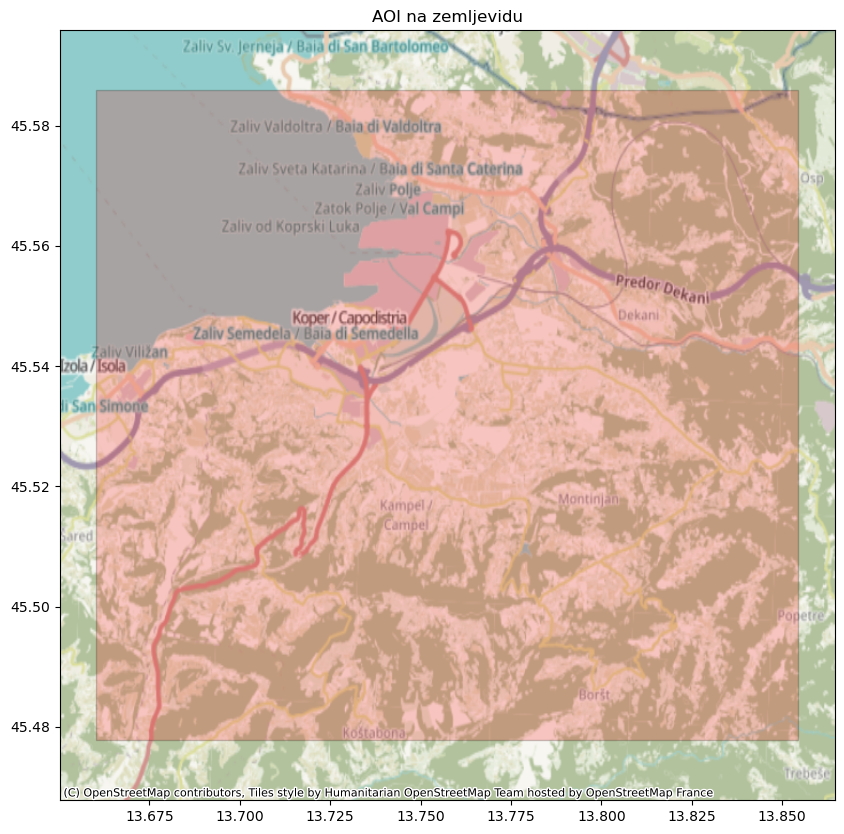

In [6]:
# Prikaz geometrije AOI na ozadju zemljevida, uporabi contextily
aoi_shape = shape(geojson_geometry)
# Pridobitev koordinatnih omejitev AOI
minx, miny, maxx, maxy = aoi_shape.bounds
# Prikaz AOI na zemljevidu
fig, ax = plt.subplots(figsize=(10, 10))
# Prikaz AOI kot rdečega poligona
x, y = aoi_shape.exterior.xy
ax.fill(x, y, alpha=0.2, fc='red', ec='black')
# Nastavitev omejitev zemljevida na AOI 
ax.set_xlim(minx - 0.01, maxx + 0.01)
ax.set_ylim(miny - 0.01, maxy + 0.01)
# Dodajanje ozadja zemljevida
ctx.add_basemap(ax, crs='EPSG:4326')
ax.set_title('AOI na zemljevidu')
plt.show()

## Nastavitve

In [7]:
# Nastavitve iskanja in naročila
ORDER_NAME = "Koper Full" # Poimenujte naročilo po želji
ITEM_TYPE = "PSScene"
PRODUCT_BUNDLE = "ortho_analytic_8b_sr" # spremeni, če tvoja konfiguracija zahteva drug asset bundle
START_DATE = "2024-07-01T00:00:00Z"
END_DATE = "2024-07-31T23:59:59Z"
MAX_CLOUD_COVER = 0.20 # 20%
AREA_COVERAGE = 0.60 # 60% - minimalna pokritost površine
CLIP_TO_AOI = False # Rezanje posnetkov na AOI (privzeto False)
BATCH_SIZE = 500 # API za naročila podpira do 500 artiklov na naročilo

In [8]:
# API endpointa za iskanje posnetkov in ustvarjanje naročil
DATA_SEARCH_URL = "https://api.planet.com/data/v1/quick-search"
ORDERS_URL = "https://api.planet.com/compute/ops/orders/v2"

### API povezave in avtentikacija

V tej sekciji določimo URL-je storitev in inicializiramo HTTP sejo z API ključem.

In [9]:
# Inicializacija HTTP seje in avtentikacije za vse API klice
SESSION = requests.Session()
SESSION.headers.update({"Content-Type": "application/json"})
SESSION.auth = (API_KEY, "")

## Pomožne funkcije

Funkcije spodaj pripravijo filter iskanja, izvajajo straničeno branje rezultatov in ustvarijo naročila.

In [10]:
# Sestava kombiniranega filtra za AOI, časovno obdobje, oblačnost in pokritost površine
def build_search_filter(aoi: Dict, start_date: str, end_date: str, max_cloud: float, min_area_coverage: float) -> Dict:
    # Sestavimo kombinirani filter: geometrija + datum + oblačnost + minimalna pokritost površine.
    return {
        "type": "AndFilter",
        "config": [
            {
                "type": "GeometryFilter",
                "field_name": "geometry",
                "config": aoi
            },
            {
                "type": "DateRangeFilter",
                "field_name": "acquired",
                "config": {
                    "gte": start_date,
                    "lte": end_date
                }
            },
            {
                "type": "RangeFilter",
                "field_name": "cloud_cover",
                "config": {
                    "lte": max_cloud
                }
            },
            {
                "type": "RangeFilter",
                "field_name": "visible_percent",
                "config": {
                    "gte": min_area_coverage
                }
            }
        ]
    }

In [11]:
# Iskanje posnetkov preko Quick Search API z avtomatskim prehajanjem po straneh
def search_items(item_type: str, search_filter: Dict, page_size: int = 250) -> Iterator[Dict]:
    body = {
        "item_types": [item_type],
        "filter": search_filter
    }

    # Začetni klic z naraščajočim časovnim vrstnim redom.
    url = f"{DATA_SEARCH_URL}?_sort=acquired%20asc&_page_size={page_size}"
    resp = SESSION.post(url, json=body)
    resp.raise_for_status()
    data = resp.json()

    # Iteriramo čez vse strani rezultatov, dokler API vrača _next povezavo.
    while True:
        for feature in data.get("features", []):
            yield feature

        next_url = data.get("_links", {}).get("_next")
        if not next_url:
            break

        next_resp = SESSION.get(next_url)
        next_resp.raise_for_status()
        data = next_resp.json()

In [12]:
# Razdeli seznam ID-jev na manjše pakete velikosti size
def chunked(seq: List[str], size: int) -> Iterator[List[str]]:
    for i in range(0, len(seq), size):
        yield seq[i:i + size]

In [13]:
# Ustvarjanje hosted naročila in vračilo API odziva
def create_hosted_order(
    order_name: str,
    item_ids: List[str],
    item_type: str,
    product_bundle: str,
    clip_to_aoi: bool = False,
    aoi_geometry: Dict | None = None
) -> Dict:
    # Nekateri navajajo asset ime (npr. ortho_analytic_8b_sr) namesto product_bundle.
    # Tu ga preslikamo na veljaven bundle za Orders API.
    bundle_aliases = {
        "ortho_analytic_8b_sr": "analytic_8b_sr_udm2",
    }
    resolved_bundle = bundle_aliases.get(product_bundle, product_bundle)
    if resolved_bundle != product_bundle:
        print(
            f"Info: product_bundle '{product_bundle}' mapped to '{resolved_bundle}' for Orders API."
        )

    # V payload vključimo hosting.sentinel_hub, da Planet ustvari novo kolekcijo.
    payload = {
        "name": order_name,
        "source_type": "scenes",
        "products": [
            {
                "item_ids": item_ids,
                "item_type": item_type,
                "product_bundle": resolved_bundle
            }
        ],
        "hosting": {
            "sentinel_hub": {
                # omit collection_id -> Planet creates a new data collection
                "create_configuration": True
            }
        }
    }

    # Opcijsko rezanje na AOI: v Orders API gre clip v tools, ne v products.
    if clip_to_aoi:
        if aoi_geometry is None:
            raise ValueError("aoi_geometry is required when clip_to_aoi=True")
        payload["tools"] = [
            {
                "clip": {
                    "aoi": aoi_geometry
                }
            }
        ]

    resp = SESSION.post(ORDERS_URL, json=payload)
    if not resp.ok:
        # Dodamo koristno diagnostiko za 4xx/5xx odzive API-ja.
        raise requests.HTTPError(
            f"{resp.status_code} {resp.reason} | {resp.text}",
            response=resp,
        )
    return resp.json()

## Iskanje posnetkov

In [14]:
# Filter za iskanje
search_filter = build_search_filter(geojson_geometry, START_DATE, END_DATE, MAX_CLOUD_COVER, AREA_COVERAGE)

In [15]:
# Iskanje posnetkov v katalogu in priprava seznama ID-jev
print("Searching Planet catalog...")
# Iz iskalnika preberemo vse najdene feature-je in izluščimo njihove ID-je.
features = list(search_items(ITEM_TYPE, search_filter))
item_ids = [f["id"] for f in features]
# Izpis skupnega števila najdenih posnetkov
print(f"Found {len(item_ids)} items")

Searching Planet catalog...
Found 54 items


In [16]:
# natisni nekaj zadetkov
for f in features[:5]:
    props = f.get("properties", {})
    print(f"- {f['id']} | acquired={props.get('acquired')} | cloud_cover={props.get('cloud_cover')}")

- 20240702_092515_80_2456 | acquired=2024-07-02T09:25:15.802595Z | cloud_cover=0.09
- 20240702_092517_53_2456 | acquired=2024-07-02T09:25:17.533795Z | cloud_cover=0.01
- 20240702_100534_83_24fc | acquired=2024-07-02T10:05:34.836183Z | cloud_cover=0
- 20240702_100537_03_24fc | acquired=2024-07-02T10:05:37.038235Z | cloud_cover=0.12
- 20240702_101600_05_2446 | acquired=2024-07-02T10:16:00.059635Z | cloud_cover=0.01


## Ustvarjanje naročil

Najdene posnetke razdelimo v pakete in za vsak paket ustvarimo ločeno naročilo.

In [17]:
# Print warning that the next step will create an order and may incur costs
print("\nWARNING: The next step will create a hosted order in your Planet account, which may incur costs based on your subscription plan. Please review the list of items above and ensure you want to proceed.")
proceed = input("Do you want to proceed with creating the order? (yes/no): ").strip().lower()
if proceed != 'yes':
    print("Order creation cancelled by user.")
    proceed = False
else:
    proceed = True
    print("Order creation proceeding.")


Order creation proceeding.


In [18]:
# create one or more orders if needed
orders = []
num_batches = math.ceil(len(item_ids) / BATCH_SIZE)

In [19]:
# Do this only if the user confirmed they want to proceed
if proceed:
    # Ustvarjanje enega ali več naročil glede na velikost batcha
    for idx, batch in enumerate(chunked(item_ids, BATCH_SIZE), start=1):
        # Če je rezultatov več kot BATCH_SIZE, jih razdelimo na več naročil.
        batch_name = f"{ORDER_NAME}-part-{idx:02d}-of-{num_batches:02d}" if num_batches > 1 else ORDER_NAME
        print(f"Creating order: {batch_name} ({len(batch)} items)")
        order = create_hosted_order(
            batch_name,
            batch,
            ITEM_TYPE,
            PRODUCT_BUNDLE,
            clip_to_aoi=CLIP_TO_AOI,
            aoi_geometry=geojson_geometry,
        )
        orders.append(order)

        order_id = order.get("id")
        state = order.get("state")
        collection_id = (
            order.get("hosting", {})
                    .get("sentinel_hub", {})
                    .get("collection_id")
        )

        print(f"  order_id: {order_id}")
        print(f"  state: {state}")
        print(f"  collection_id: {collection_id}")
else:
    print("No orders were created. Exiting.")

Creating order: Koper Full (54 items)
Info: product_bundle 'ortho_analytic_8b_sr' mapped to 'analytic_8b_sr_udm2' for Orders API.
  order_id: 216422d1-bfc5-4c56-8b5e-108aa9d0dee8
  state: queued
  collection_id: 8b600ed9-0b02-4576-96c9-d302046f5dcb


## Povzetek rezultatov

Na koncu izpišemo vsa ustvarjena naročila in njihovo trenutno stanje.

In [20]:
# Končni izpis ustvarjenih naročil in njihovih stanj
print("\nDone.")
print("Created orders:")
for order in orders:
    print(f"- {order.get('id')} | {order.get('name')} | {order.get('state')}")


Done.
Created orders:
- 216422d1-bfc5-4c56-8b5e-108aa9d0dee8 | Koper Full | queued
